## Amazon Sales Report

##### Importing the required Libraries

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

##### Introduction to the dataset

In [91]:
# Loading the dataset
df = pd.read_csv("Amazon_Sale_Report.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [92]:
# Shape of the dataset
df.shape

(128976, 21)

In [93]:
# Display the first 5 rows of the dataset
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [ ]:
# Display the information about the dataset, including column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [ ]:
# Display the summary statistics of the dataset, including count, mean, standard deviation, minimum, maximum, and quartiles for numerical columns
df.describe()


,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [ ]:
# Display the data types of each column in the dataset
df.dtypes

order_id               object
Date                   object
status                 object
fulfilment             object
sales_channel          object
ship_service_level     object
category               object
size                   object
courier_status         object
qty                     int64
currency               object
amount                float64
ship_city              object
ship_state             object
ship_postal_code      float64
ship_country           object
b2b                      bool
dtype: object

In [ ]:
# Display the number of missing values in each column of the dataset
df.isnull().sum()

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [119]:
df.duplicated().sum()

np.int64(0)

In [118]:
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Order IDs:", df['order_id'].duplicated().sum())

Duplicate Rows: 0
Duplicate Order IDs: 8574


In [120]:
df[df['order_id'] == df['order_id'].value_counts().idxmax()]

,index,order_id,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b
74586,74585,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Perfume,Free,On the Way,0,INR,797.14,CHENNAI,TAMIL NADU,600044.0,IN,False
74587,74586,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Shirt,3XL,On the Way,0,INR,463.81,CHENNAI,TAMIL NADU,600044.0,IN,False
74588,74587,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Shirt,XXL,On the Way,0,INR,385.71,CHENNAI,TAMIL NADU,600044.0,IN,False
74589,74588,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Shirt,3XL,On the Way,0,INR,380.00,CHENNAI,TAMIL NADU,600044.0,IN,False
74590,74589,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Shirt,3XL,On the Way,0,INR,332.38,CHENNAI,TAMIL NADU,600044.0,IN,False
74591,74590,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,T-shirt,3XL,On the Way,0,INR,651.43,CHENNAI,TAMIL NADU,600044.0,IN,False
74592,74591,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,T-shirt,3XL,On the Way,0,INR,652.38,CHENNAI,TAMIL NADU,600044.0,IN,False
74593,74592,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Trousers,XXL,On the Way,0,INR,380.00,CHENNAI,TAMIL NADU,600044.0,IN,False
74594,74593,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Shirt,3XL,On the Way,0,INR,414.29,CHENNAI,TAMIL NADU,600044.0,IN,False
74595,74594,171-5057375-2831560,Cancelled,Merchant,Amazon.in,Standard,Blazzer,3XL,On the Way,0,INR,665.71,CHENNAI,TAMIL NADU,600044.0,IN,False


##### Handling Duplicate datas

In [114]:
df[df.duplicated()]

,index,order_id,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b
201,6,408-5748499-6859555,Shipped,Amazon,Amazon.in,Expedited,T-shirt,L,Shipped,1,INR,653.0,CHANDIGARH,CHANDIGARH,160036.0,IN,False
202,7,406-7807733-3785945,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,S,Shipped,1,INR,399.0,HYDERABAD,TELANGANA,500032.0,IN,False
203,8,407-5443024-5233168,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,Cancelled,0,INR,NaN,HYDERABAD,TELANGANA,500008.0,IN,False
204,9,402-4393761-0311520,Shipped,Amazon,Amazon.in,Expedited,Shirt,XXL,Shipped,1,INR,363.0,Chennai,TAMIL NADU,600041.0,IN,False
205,10,407-5633625-6970741,Shipped,Amazon,Amazon.in,Expedited,Shirt,S,Shipped,1,INR,685.0,CHENNAI,TAMIL NADU,600073.0,IN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6640,6278,171-5170733-7855514,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,XS,Shipped,1,INR,582.0,HYDERABAD,TELANGANA,500083.0,IN,False
6641,6279,403-8137343-5206760,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,XS,Shipped,1,INR,801.0,KALPETTA,KERALA,673122.0,IN,False
6642,6280,408-1575454-3263526,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,Blazzer,M,Shipped,1,INR,690.0,CHENNAI,TAMIL NADU,600049.0,IN,False
6643,6281,171-2918708-7197155,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Blazzer,XXL,Shipped,1,INR,658.0,PUNE,MAHARASHTRA,412207.0,IN,False


In [115]:
df = df.drop_duplicates()

In [116]:
print(df.duplicated().sum())

0


##### Handling Missing datas

In [97]:
df.drop(columns=['New', 'PendingS'], inplace=True)

In [121]:
df.drop(columns='index', inplace=True)

In [98]:
df.dropna(subset=[
    'ship-city',
    'ship-state',
    'ship-postal-code',
    'ship-country'
], inplace=True)

In [99]:
df.loc[
    (df['currency'].isna()) & (df['ship-country'] == 'IN'),
    'currency'
] = 'INR'

In [100]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Category                  0
Size                      0
Courier Status            0
Qty                       0
currency                  0
Amount                 7798
ship-city                 0
ship-state                0
ship-postal-code          0
ship-country              0
B2B                       0
fulfilled-by          89691
dtype: int64

In [101]:
df[df['Amount'].isnull()]['Courier Status'].value_counts()

Courier Status
Cancelled     5938
On the Way    1736
Unshipped      124
Name: count, dtype: int64

In [102]:
df[df['Courier Status'] == 'Unshipped']['Sales Channel'].value_counts()

Sales Channel
Amazon.in     6554
Non-Amazon     124
Name: count, dtype: int64

In [103]:
print(df['Courier Status'].value_counts())

print("\nSales Channel for Unshipped orders:")
print(df[df['Courier Status'] == 'Unshipped']['Sales Channel'].value_counts())

Courier Status
Shipped       109458
On the Way      6867
Unshipped       6678
Cancelled       5938
Name: count, dtype: int64

Sales Channel for Unshipped orders:
Sales Channel
Amazon.in     6554
Non-Amazon     124
Name: count, dtype: int64


In [104]:
pd.crosstab(
    df['Fulfilment'],
    df['fulfilled-by'],
    dropna=False
)

fulfilled-by,Easy Ship,NaN
Fulfilment,,
Amazon,0,89691
Merchant,39250,0


In [105]:
df.drop(columns=['fulfilled-by'], inplace=True)

In [106]:
print(df['Status'].unique())
print(df['Courier Status'].unique())

['Cancelled' 'Shipped - Delivered to Buyer' 'Shipped'
 'Shipped - Returned to Seller' 'Shipped - Rejected by Buyer'
 'Shipped - Lost in Transit' 'Shipped - Out for Delivery'
 'Shipped - Returning to Seller' 'Shipped - Picked Up' 'Pending'
 'Pending - Waiting for Pick Up' 'Shipped - Damaged' 'Shipping']
['On the Way' 'Shipped' 'Cancelled' 'Unshipped']


In [107]:
df.columns


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B'],
      dtype='object')

In [108]:
df.drop(columns=['Date'], inplace=True)

In [109]:
# Convert column names to snake_case for consistency and easier access

df.rename(columns={
    'Order ID': 'order_id',
    'Status': 'status',
    'Fulfilment': 'fulfilment',
    'Sales Channel': 'sales_channel',
    'ship-service-level': 'ship_service_level',
    'Category': 'category',
    'Size': 'size',
    'Courier Status': 'courier_status',
    'Qty': 'qty',
    'currency': 'currency',
    'Amount': 'amount',
    'ship-city': 'ship_city',
    'ship-state': 'ship_state',
    'ship-postal-code': 'ship_postal_code',
    'ship-country': 'ship_country',
    'B2B': 'b2b',
    'Year': 'year',
    'Month': 'month',
    'Month_Number': 'month_number',
    'Day': 'day',
    'Weekday': 'weekday'
}, inplace=True)


In [110]:
# Display the first 20 rows of orders with a quantity of 0, showing relevant columns for analysis (To Confirm that qty is 0 means status is Cancelled)

df[df['qty'] == 0][[
    'order_id',
    'status',
    'courier_status',
    'amount',
    'qty',
    'category'
]].head(20)

,order_id,status,courier_status,amount,qty,category
0,405-8078784-5731545,Cancelled,On the Way,647.62,0,T-shirt
3,403-9615377-8133951,Cancelled,On the Way,753.33,0,Blazzer
8,407-5443024-5233168,Cancelled,Cancelled,NaN,0,T-shirt
23,404-6019946-2909948,Cancelled,On the Way,570.48,0,T-shirt
29,404-5933402-8801952,Cancelled,On the Way,NaN,0,Shirt
65,171-4137548-0481151,Cancelled,Cancelled,NaN,0,Shirt
83,404-6522553-9345930,Cancelled,On the Way,1105.36,0,T-shirt
84,403-9950518-0349133,Cancelled,Cancelled,NaN,0,Shirt
95,405-9112089-3379536,Cancelled,Cancelled,NaN,0,Shirt
101,402-7841951-1872363,Cancelled,Cancelled,NaN,0,T-shirt


In [111]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(categorical_cols)

['order_id', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'category', 'size', 'courier_status', 'currency', 'ship_city', 'ship_state', 'ship_country', 'b2b']


In [112]:
df.dtypes


index                   int64
order_id               object
status                 object
fulfilment             object
sales_channel          object
ship_service_level     object
category               object
size                   object
courier_status         object
qty                     int64
currency               object
amount                float64
ship_city              object
ship_state             object
ship_postal_code      float64
ship_country           object
b2b                      bool
dtype: object

##### Exploratory Data Analysis (EDA) and Visualization

In [122]:
# Categorical columns and Numerical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(categorical_cols)
print()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)

['order_id', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'category', 'size', 'courier_status', 'currency', 'ship_city', 'ship_state', 'ship_country', 'b2b']

['qty', 'amount', 'ship_postal_code']


In [123]:
print("Total Rows:", len(df))
print("Unique Orders:", df['order_id'].nunique())
print("Average Items per Order:", len(df) / df['order_id'].nunique())

Total Rows: 128775
Unique Orders: 120201
Average Items per Order: 1.071330521376694


##### Univariate Analysis

In [ ]:
# order_id
'''order_id is a unique business identifier used to distinguish customer orders.
 It is not an analytical feature but is valuable for validating data integrity, 
 counting unique orders, and identifying multi-item orders.'''

In [125]:
s = df['status'].unique()
for i in s:
    print(i, ":", len(df[df['status'] == i]))

Cancelled : 18304
Shipped - Delivered to Buyer : 28708
Shipped : 77697
Shipped - Returned to Seller : 1949
Shipped - Rejected by Buyer : 11
Shipped - Lost in Transit : 5
Shipped - Out for Delivery : 35
Shipped - Returning to Seller : 145
Shipped - Picked Up : 973
Pending : 658
Pending - Waiting for Pick Up : 281
Shipped - Damaged : 1
Shipping : 8


In [126]:
status_percent = (
    df['status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percent)

status
Shipped                          60.34
Shipped - Delivered to Buyer     22.29
Cancelled                        14.21
Shipped - Returned to Seller      1.51
Shipped - Picked Up               0.76
Pending                           0.51
Pending - Waiting for Pick Up     0.22
Shipped - Returning to Seller     0.11
Shipped - Out for Delivery        0.03
Shipped - Rejected by Buyer       0.01
Shipping                          0.01
Shipped - Lost in Transit         0.00
Shipped - Damaged                 0.00
Name: proportion, dtype: float64


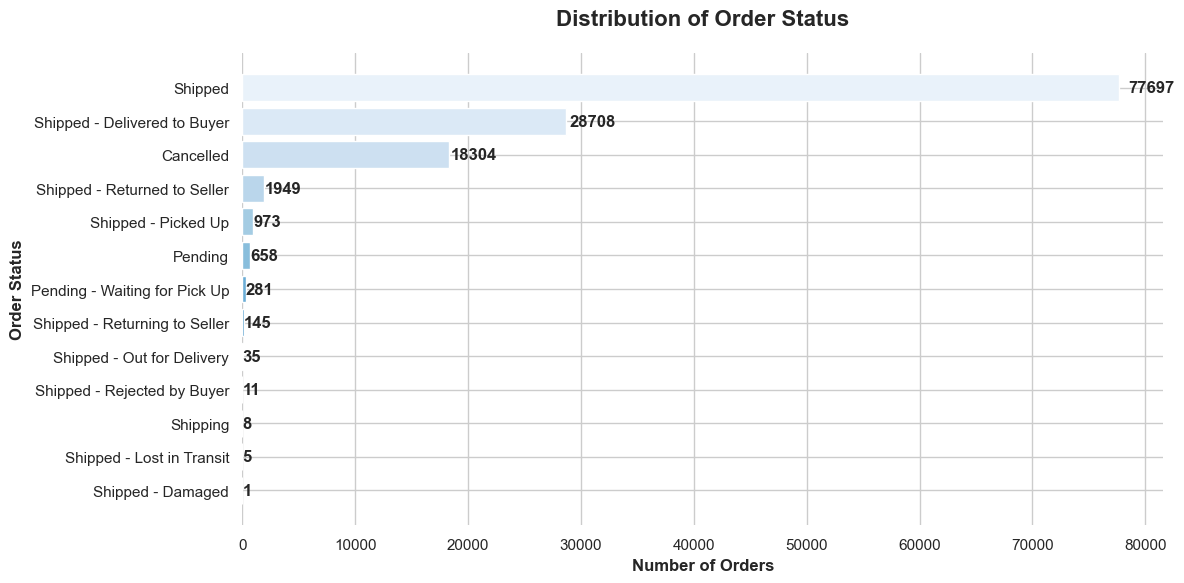

In [129]:
# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Calculate counts and sort in ascending order
status_counts = df['status'].value_counts().sort_values()

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create horizontal bar chart with a professional color palette
bars = ax.barh(status_counts.index, status_counts.values, color=sns.color_palette("Blues_r", len(status_counts)))

# Add data labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
            f'{int(width)}', 
            ha='left', va='center', fontweight='bold')

# Customize titles and labels
ax.set_title('Distribution of Order Status', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Number of Orders', fontsize=12, fontweight='bold')
ax.set_ylabel('Order Status', fontsize=12, fontweight='bold')

# Clean up axes
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
# status
'''The large number of shipped and delivered orders indicates an active fulfilment process.
However, the relatively high number of cancelled orders suggests an opportunity to investigate
cancellation causes and improve order completion rates. Rare statuses like damaged or lost shipments
indicate that logistics issues are minimal.'''

In [131]:
(df['fulfilment'].value_counts(normalize=True) * 100).round(2)

fulfilment
Amazon      69.56
Merchant    30.44
Name: proportion, dtype: float64

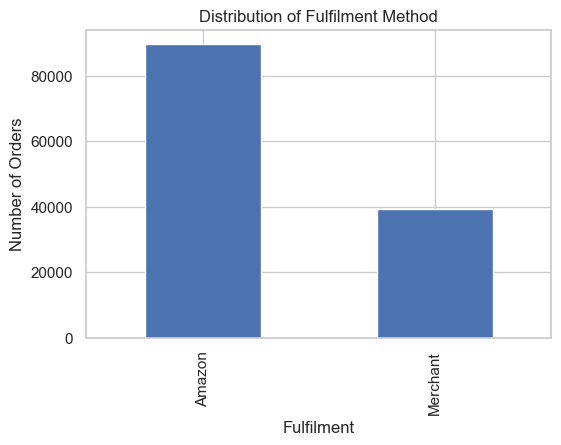

In [132]:
fulfilment_counts = df['fulfilment'].value_counts()

plt.figure(figsize=(6,4))
fulfilment_counts.plot(kind='bar')

plt.title("Distribution of Fulfilment Method")
plt.xlabel("Fulfilment")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
# fulfilment
'''Amazon is the primary fulfilment method,
suggesting that the business relies more on Amazon's
fulfilment network than merchant-managed fulfilment.'''

In [133]:
(df['sales_channel'].value_counts(normalize=True) * 100).round(2)

sales_channel
Amazon.in     99.9
Non-Amazon     0.1
Name: proportion, dtype: float64

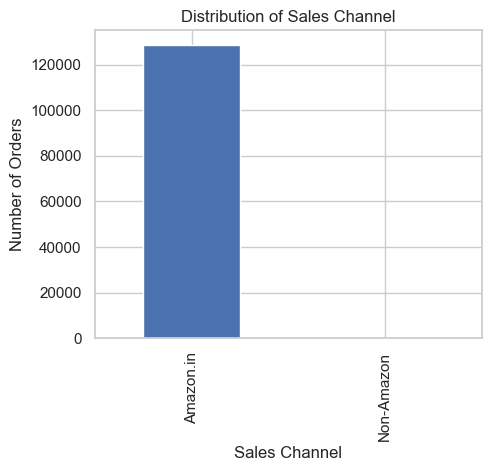

In [134]:
sales_channel_counts = df['sales_channel'].value_counts()

plt.figure(figsize=(5,4))

sales_channel_counts.plot(kind='bar')

plt.title("Distribution of Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
# sales_channel
'''The business is heavily dependent on Amazon.in as
its primary sales channel, indicating very limited sales through alternative
channels.'''

In [135]:
df['ship_service_level'].value_counts()

ship_service_level
Expedited    88493
Standard     40282
Name: count, dtype: int64

In [136]:
(df['ship_service_level'].value_counts(normalize=True) * 100).round(2)

ship_service_level
Expedited    68.72
Standard     31.28
Name: proportion, dtype: float64

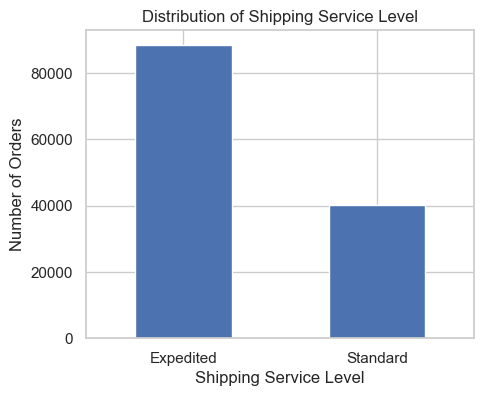

In [137]:
ship_service = df['ship_service_level'].value_counts()

plt.figure(figsize=(5,4))

ship_service.plot(kind='bar')

plt.title("Distribution of Shipping Service Level")
plt.xlabel("Shipping Service Level")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# ship_service_level
'''Expedited shipping is the dominant shipping method in the dataset, 
suggesting that the business primarily processes orders through faster delivery services.'''

In [140]:
df['category'].value_counts()

category
T-shirt     50207
Shirt       49786
Blazzer     15488
Trousers    10605
Perfume      1157
Wallet        926
Socks         439
Shoes         164
Watch           3
Name: count, dtype: int64

In [141]:
(df['category'].value_counts(normalize=True) * 100).round(2)

category
T-shirt     38.99
Shirt       38.66
Blazzer     12.03
Trousers     8.24
Perfume      0.90
Wallet       0.72
Socks        0.34
Shoes        0.13
Watch        0.00
Name: proportion, dtype: float64

In [ ]:
# category
'''Approximately 98% of the orders belong to apparel categories (T-shirt, Shirt, Blazzer, and Trousers),
while accessories such as Perfume, Wallet, Socks, Shoes, and Watch account for only a small proportion of the total orders.'''

In [142]:
df['size'].value_counts()

size
M       22343
L       21768
XL      20516
XXL     17780
S       16748
3XL     14625
XS      11032
Free     2250
6XL       738
5XL       550
4XL       425
Name: count, dtype: int64

In [143]:
(df['size'].value_counts(normalize=True) * 100).round(2)

size
M       17.35
L       16.90
XL      15.93
XXL     13.81
S       13.01
3XL     11.36
XS       8.57
Free     1.75
6XL      0.57
5XL      0.43
4XL      0.33
Name: proportion, dtype: float64

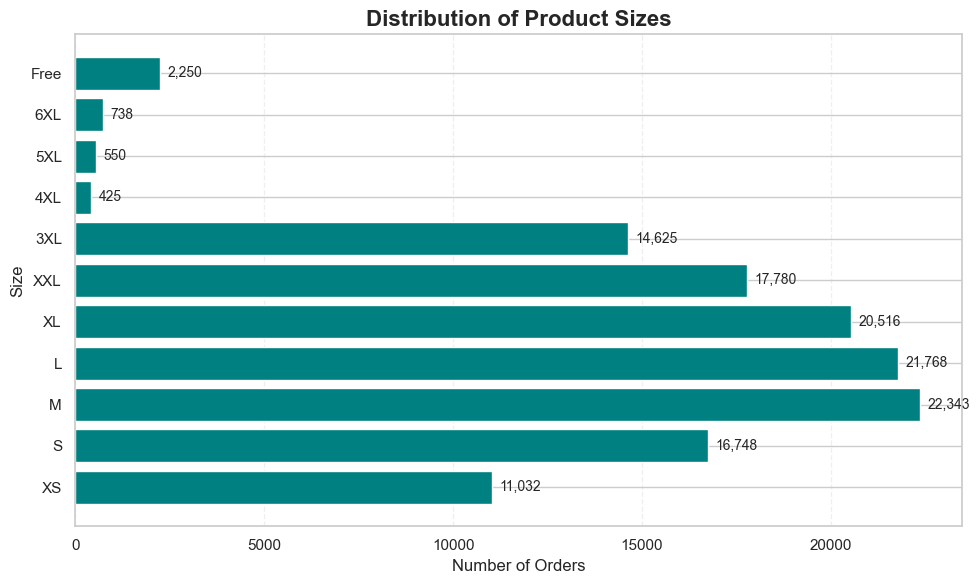

In [147]:
import matplotlib.pyplot as plt

# Define the logical order of sizes
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']

# Count values and arrange them in the logical order
size_counts = df['size'].value_counts().reindex(size_order)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.barh(size_counts.index, size_counts.values, color='teal')

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center',
        fontsize=10
    )

plt.title('Distribution of Product Sizes', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Size', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# size
'''The majority of orders fall within the medium-to-extra-large size range (M to XXL),
indicating that these sizes account for the largest share of order volume.'''

In [148]:
df['courier_status'].value_counts()

courier_status
Shipped       109315
On the Way      6860
Unshipped       6673
Cancelled       5927
Name: count, dtype: int64

In [149]:
(df['courier_status'].value_counts(normalize=True) * 100).round(2)

courier_status
Shipped       84.89
On the Way     5.33
Unshipped      5.18
Cancelled      4.60
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(df['status'], df['courier_status'])

courier_status,Cancelled,On the Way,Shipped,Unshipped
status,,,,
Cancelled,5832,6849,0,5623
Pending,2,0,10,646
Pending - Waiting for Pick Up,0,0,0,281
Shipped,93,0,77489,115
Shipped - Damaged,0,0,1,0
Shipped - Delivered to Buyer,0,8,28700,0
Shipped - Lost in Transit,0,0,5,0
Shipped - Out for Delivery,0,0,35,0
Shipped - Picked Up,0,0,973,0


In [ ]:
# courier_status
'''The majority of orders (84.89%) have successfully progressed to the shipped stage, indicating an efficient order fulfillment process.
 Only a small proportion of orders remain in transit, unshipped, or cancelled.'''

In [151]:
df['qty'].describe()

count    128775.000000
mean          0.904430
std           0.313359
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          15.000000
Name: qty, dtype: float64

In [152]:
df['qty'].value_counts().sort_index()

qty
0      12787
1     115601
2        340
3         32
4          9
5          2
8          1
9          1
13         1
15         1
Name: count, dtype: int64

In [153]:
(df['qty'].value_counts(normalize=True) * 100).round(2)

qty
1     89.77
0      9.93
2      0.26
3      0.02
4      0.01
5      0.00
9      0.00
15     0.00
13     0.00
8      0.00
Name: proportion, dtype: float64

In [154]:
df[df['qty'] == 0]['status'].value_counts()

status
Cancelled                       12681
Shipped                            93
Shipped - Delivered to Buyer        8
Shipped - Returned to Seller        3
Pending                             2
Name: count, dtype: int64

In [155]:
df[df['status'] != 'Cancelled']['qty'].mean()

np.float64(1.0031501480026432)

In [156]:
df[(df['status'] != 'Cancelled') & (df['qty'] > 0)]['qty'].mean()

np.float64(1.0041136229782992)

In [ ]:
# qty
'''The majority of order items have a quantity of 1. Approximately 99% of zero-quantity records are associated with cancelled orders, while a very small number appear under other order statuses.'''
'''Most transactions involve a single unit per order item. Zero-quantity records are overwhelmingly linked to cancelled orders, indicating that order cancellations are the primary reason for zero recorded quantities.'''
'''The median quantity is 1, and after excluding cancelled orders, the average quantity is also 1. This indicates that successful transactions typically involve the purchase of a single unit per order item.'''

In [158]:
amount = df['amount'].dropna()
amount.describe()

count    120988.000000
mean        648.643794
std         281.235025
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: amount, dtype: float64

In [159]:
print("Missing Values:", df['amount'].isna().sum())

print("Percentage:",
      round(df['amount'].isna().mean()*100,2), "%")

Missing Values: 7787
Percentage: 6.05 %


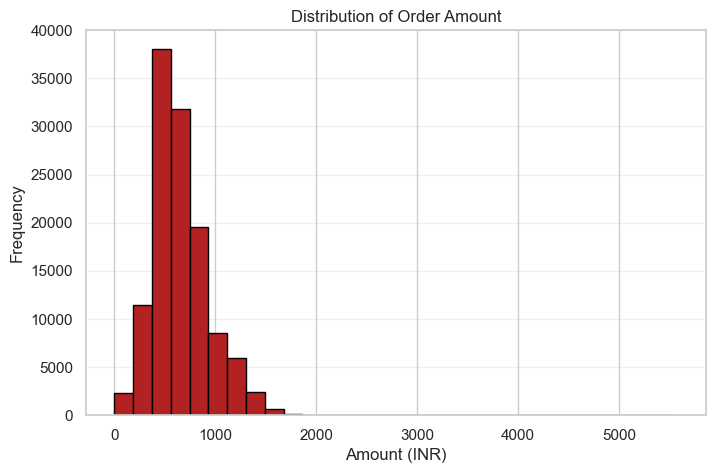

In [162]:
plt.figure(figsize=(8,5))

plt.hist(amount, bins=30, color='firebrick', edgecolor='black')

plt.title("Distribution of Order Amount")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.3)

plt.show()

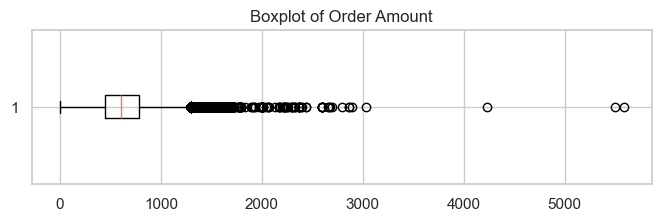

In [164]:
plt.figure(figsize=(8,2))

plt.boxplot(amount, vert=False)

plt.title("Boxplot of Order Amount")

plt.show()

In [ ]:
# amount 
'''The order amount distribution is positively skewed, with most orders
falling in the lower price range and a small number of high-value
transactions creating several upper-end outliers.'''
'''The average order amount is ₹648.64, while the median is ₹605,
indicating a positively skewed distribution influenced by a small number of high-value orders.'''
'''Half of the valid order amounts fall between ₹449 and ₹788,
suggesting that most transactions occur within a moderate price range.'''
'''The maximum recorded order amount is ₹5,584, showing the presence 
of a few high-value transactions that contribute to the upper tail of the distribution.'''

In [176]:
df['ship_city'] = df['ship_city'].str.strip().str.title()

In [177]:
(df['ship_city'].value_counts(normalize=True).head(10) * 100).round(2)

ship_city
Bengaluru    9.22
Hyderabad    7.08
Mumbai       5.52
New Delhi    4.91
Chennai      4.88
Pune         3.58
Kolkata      2.21
Gurugram     1.52
Thane        1.46
Lucknow      1.26
Name: proportion, dtype: float64

In [178]:
(df['ship_city'].value_counts(normalize=True) * 100).round(2)

ship_city
Bengaluru                9.22
Hyderabad                7.08
Mumbai                   5.52
New Delhi                4.91
Chennai                  4.88
                         ... 
Kaliachak ; Golapgonj    0.00
Baddi Industrial Area    0.00
Dokmoka                  0.00
Badlapur , Thane         0.00
Bangluru                 0.00
Name: proportion, Length: 7291, dtype: float64

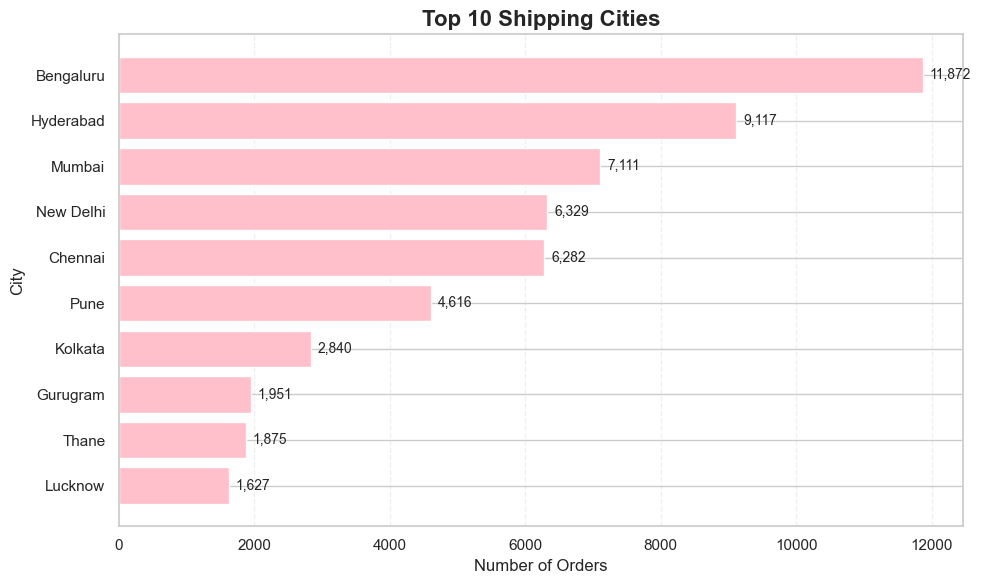

In [179]:
import matplotlib.pyplot as plt

top_cities = df['ship_city'].value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(top_cities.index[::-1], top_cities.values[::-1], color='pink')

for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center',
        fontsize=10
    )

plt.title("Top 10 Shipping Cities", fontsize=16, fontweight='bold')
plt.xlabel("Number of Orders")
plt.ylabel("City")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ship_city
'''Bengaluru is the largest market in terms of order volume, 
followed by Hyderabad and Mumbai.'''
'''The top five metropolitan cities together contribute a
significant share of total orders, indicating that demand is
concentrated in major urban centers.'''
'''The business has strong penetration in India's metropolitan regions,
suggesting that urban areas form the primary customer base.'''

In [ ]:
'''Bengaluru accounts for 9.22% of all orders, making it the largest shipping destination in the dataset. The top five metropolitan cities together contribute a substantial share of total order volume, highlighting the concentration of demand in urban markets.'''

In [181]:
df['ship_state'] = df['ship_state'].str.strip().str.title()

In [182]:
df['ship_state'].value_counts().head(10)

ship_state
Maharashtra       22234
Karnataka         17296
Tamil Nadu        11470
Telangana         11319
Uttar Pradesh     10633
Delhi              6954
Kerala             6574
West Bengal        5955
Andhra Pradesh     5421
Gujarat            4479
Name: count, dtype: int64

In [183]:
(df['ship_state'].value_counts(normalize=True).head(10) * 100).round(2)

ship_state
Maharashtra       17.27
Karnataka         13.43
Tamil Nadu         8.91
Telangana          8.79
Uttar Pradesh      8.26
Delhi              5.40
Kerala             5.11
West Bengal        4.62
Andhra Pradesh     4.21
Gujarat            3.48
Name: proportion, dtype: float64

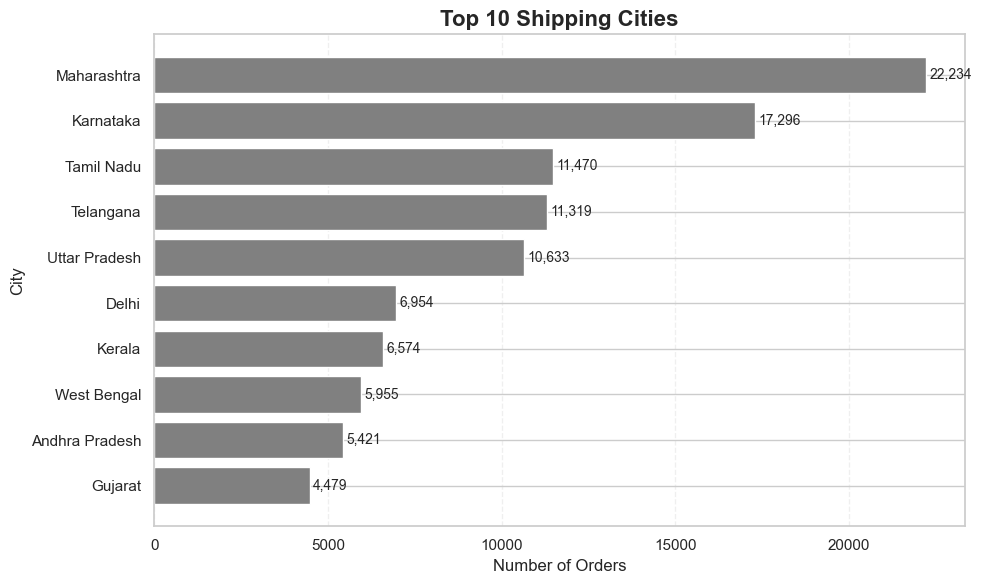

In [ ]:
import matplotlib.pyplot as plt

top_cities = df['ship_state'].value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(top_cities.index[::-1], top_cities.values[::-1], color='gray')

for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center',
        fontsize=10
    )

plt.title("Top 10 Shipping States", fontsize=16, fontweight='bold')
plt.xlabel("Number of Orders")
plt.ylabel("City")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ship_state
'''Maharashtra contributes the highest number of orders (17.27%), making it the largest market in the dataset.'''
'''Over half (56.66%) of all orders come from just five states.'''

In [188]:
df['ship_country'].value_counts()

ship_country
IN    128775
Name: count, dtype: int64

In [ ]:
'''The dataset represents domestic shipments only,
indicating that the analysis focuses exclusively on the Indian market.
Therefore, international shipping trends cannot be analyzed using this dataset.'''

In [189]:
df['b2b'].value_counts()

b2b
False    127904
True        871
Name: count, dtype: int64

In [190]:
(df['b2b'].value_counts(normalize=True) * 100).round(2)

b2b
False    99.32
True      0.68
Name: proportion, dtype: float64

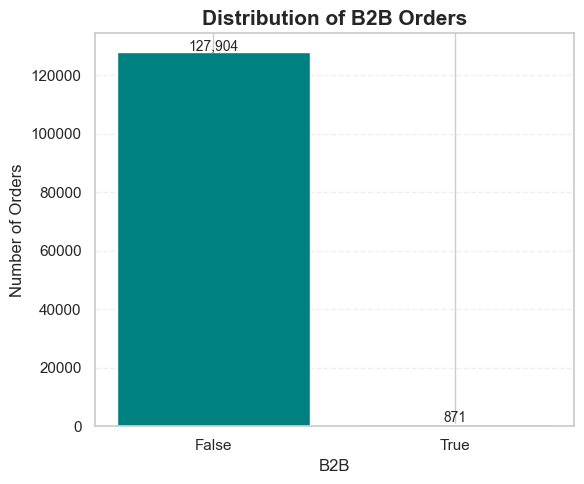

In [191]:
import matplotlib.pyplot as plt

b2b_counts = df['b2b'].value_counts()

plt.figure(figsize=(6,5))

bars = plt.bar(
    b2b_counts.index.astype(str),
    b2b_counts.values,
    color=['teal', 'coral']
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{int(bar.get_height()):,}',
        ha='center',
        fontsize=10
    )

plt.title("Distribution of B2B Orders", fontsize=15, fontweight='bold')
plt.xlabel("B2B")
plt.ylabel("Number of Orders")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# b2b
'''The vast majority of orders (99.32%) are Business-to-Consumer (B2C) transactions.'''
'''Only 0.68% of orders are Business-to-Business (B2B), indicating that business purchases are extremely limited.'''
'''B2B orders represent less than 1% of total transactions, suggesting that wholesale or corporate sales contribute only a small portion of the order volume.'''

In [208]:
month_percent = (df['month'].value_counts(normalize=True) * 100).round(2)

# Sort chronologically
month_order = ['January', 'February', 'March', 'April', 'May',
               'June', 'July', 'August', 'September', 'October',
               'November', 'December']

month_percent = month_percent.reindex(month_order).dropna()

print(month_percent)

month
March     0.14
April    37.98
May      32.67
June     29.22
Name: proportion, dtype: float64


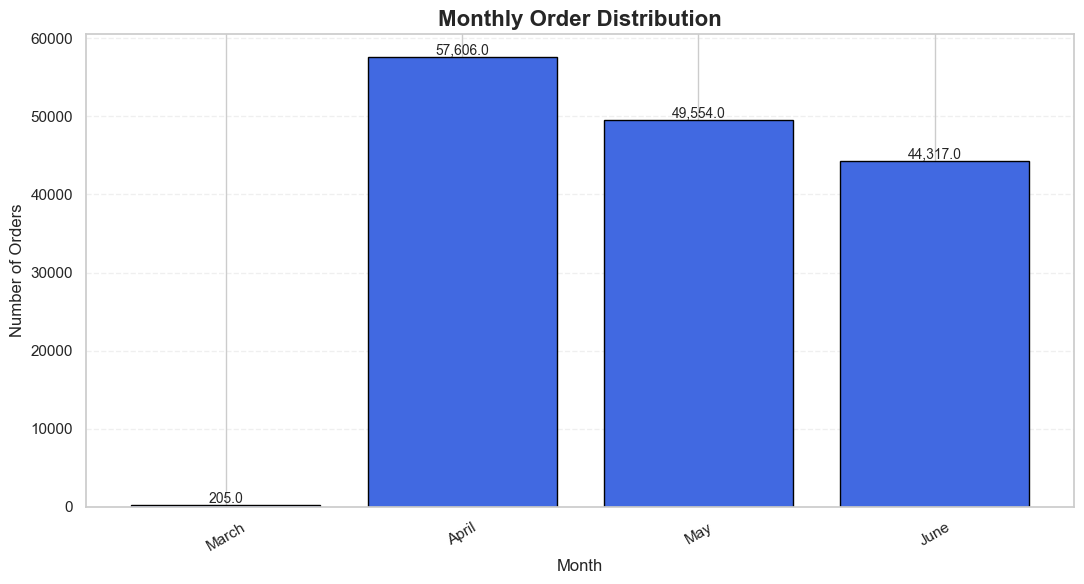

In [209]:
import matplotlib.pyplot as plt

month_counts = df['month'].value_counts().reindex(month_order).dropna()

plt.figure(figsize=(11,6))

bars = plt.bar(
    month_counts.index,
    month_counts.values,
    color='royalblue',
    edgecolor='black'
)

# Add values
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 300,
        f'{bar.get_height():,}',
        ha='center',
        fontsize=10
    )

plt.title("Monthly Order Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# month
'''The dataset primarily covers April to June, with April accounting for the highest share of orders. March contributes a negligible percentage because it contains only partial-month data.'''

In [210]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday',
                 'Friday','Saturday','Sunday']

weekday_percent = (df['weekday'].value_counts(normalize=True)*100).round(2)
weekday_percent = weekday_percent.reindex(weekday_order)

print(weekday_percent)

weekday
Monday       14.54
Tuesday      14.67
Wednesday    14.49
Thursday     13.09
Friday       13.56
Saturday     14.34
Sunday       15.31
Name: proportion, dtype: float64


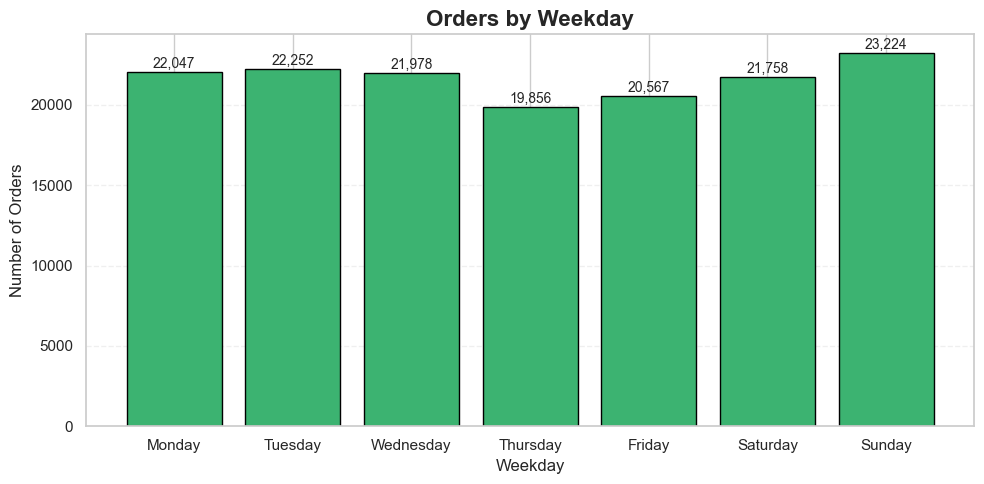

In [211]:
weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10,5))

bars = plt.bar(
    weekday_counts.index,
    weekday_counts.values,
    color='mediumseagreen',
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+250,
        f'{bar.get_height():,}',
        ha='center',
        fontsize=10
    )

plt.title("Orders by Weekday", fontsize=16, fontweight='bold')
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# weekday
'''Order distribution is relatively uniform throughout the week, indicating consistent customer purchasing behavior across different weekdays.'''

##### Bivariate EDA

In [192]:
df_b2c = df[df['b2b'] == False]

In [193]:
print("Overall Dataset")
print(df['amount'].describe())

print("\nB2C Dataset")
print(df_b2c['amount'].describe())

Overall Dataset
count    120988.000000
mean        648.643794
std         281.235025
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: amount, dtype: float64

B2C Dataset
count    120145.000000
mean        648.274124
std         280.786616
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: amount, dtype: float64


In [194]:
print("Overall Revenue:", df['amount'].sum())
print("B2C Revenue:", df_b2c['amount'].sum())

Overall Revenue: 78478115.39
B2C Revenue: 77886894.6


In [195]:
print("Overall Mean Amount:", df['amount'].mean())
print("B2C Mean Amount:", df_b2c['amount'].mean())

Overall Mean Amount: 648.6437943432406
B2C Mean Amount: 648.2741237671147


In [196]:
df.groupby('b2b')['amount'].agg(['count', 'mean', 'median', 'sum', 'max'])

,count,mean,median,sum,max
b2b,,,,,
False,120145,648.274124,605.0,77886894.60,5584.0
True,843,701.329526,665.0,591220.79,5495.0


In [ ]:
'''Although B2B orders account for less than 1% of total transactions, they have a higher average and median order value than B2C orders, indicating that business customers tend to place higher-value orders.'''

In [197]:
df.columns

Index(['order_id', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'category', 'size', 'courier_status', 'qty',
       'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code',
       'ship_country', 'b2b'],
      dtype='object')

In [202]:
# Read original dataset
df_original = pd.read_csv("Amazon_Sale_Report.csv")

# Check if rows match
print(df.shape)
print(df_original.shape)

df_original['Date'] = pd.to_datetime(df_original['Date'])

(128775, 22)
(128976, 21)


In [203]:
df = df.merge(
    df_original[['Order ID', 'Date']],
    left_on='order_id',
    right_on='Order ID',
    how='left'
)

In [204]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month_name()
df['month_number'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.day_name()

In [205]:
df.drop(columns=['Order ID', 'Date'], inplace=True)

In [206]:
df.head()


,order_id,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,...,ship_state,ship_postal_code,ship_country,b2b,date,year,month,month_number,day,weekday
0,405-8078784-5731545,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,...,Maharashtra,400081.0,IN,False,2022-04-30,2022,April,4,30,Saturday
1,171-9198151-1101146,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,...,Karnataka,560085.0,IN,False,2022-04-30,2022,April,4,30,Saturday
2,404-0687676-7273146,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,...,Maharashtra,410210.0,IN,True,2022-04-30,2022,April,4,30,Saturday
3,403-9615377-8133951,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,...,Puducherry,605008.0,IN,False,2022-04-30,2022,April,4,30,Saturday
4,407-1069790-7240320,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,...,Tamil Nadu,600073.0,IN,False,2022-04-30,2022,April,4,30,Saturday


In [207]:
df.to_csv("amazon_sales_cleaned.csv", index=False)

In [212]:
pd.crosstab(
    df['fulfilment'],
    df['status'],
    normalize='index'
) * 100

status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
fulfilment,,,,,,,,,,,,,
Amazon,12.769559,0.567090,0.000000,86.655701,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00765
Merchant,17.294590,0.719547,0.740772,0.000000,0.002123,73.699404,0.014858,0.087025,2.362405,0.023348,4.654766,0.401163,0.00000


In [213]:
# Create a copy of status
df['status_group'] = df['status']

# Group statuses
df.loc[df['status'] == 'Cancelled', 'status_group'] = 'Cancelled'

df.loc[df['status'].isin([
    'Pending',
    'Pending - Waiting for Pick Up'
]), 'status_group'] = 'Pending'

df.loc[
    df['status'].str.startswith('Shipped') | (df['status'] == 'Shipping'),
    'status_group'
] = 'Shipped'

In [214]:
status_fulfilment = (
    pd.crosstab(
        df['fulfilment'],
        df['status_group'],
        normalize='index'
    ) * 100
).round(2)

print(status_fulfilment)

status_group  Cancelled  Pending  Shipped
fulfilment                               
Amazon            12.77     0.57    86.66
Merchant          17.29     1.46    81.25


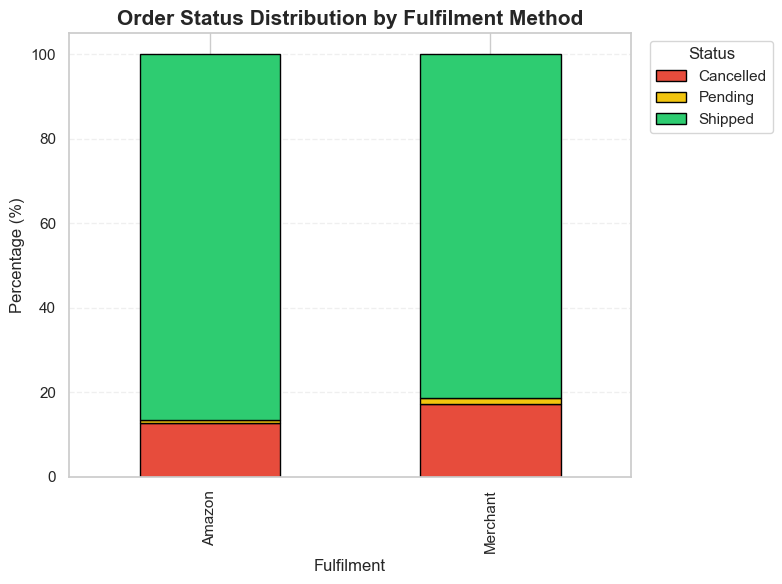

In [215]:
import matplotlib.pyplot as plt

status_fulfilment.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#e74c3c', '#f1c40f', '#2ecc71'],
    edgecolor='black'
)

plt.title(
    "Order Status Distribution by Fulfilment Method",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Fulfilment")
plt.ylabel("Percentage (%)")

plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
'''Merchant-fulfilled orders have a higher cancellation rate (17.29%) than Amazon-fulfilled orders (12.77%). Amazon fulfilment shows a higher proportion of shipped orders, indicating comparatively better order completion performance.'''

In [216]:
service_status = (
    pd.crosstab(
        df['ship_service_level'],
        df['status_group'],
        normalize='index'
    ) * 100
).round(2)

print(service_status)

status_group        Cancelled  Pending  Shipped
ship_service_level                             
Expedited               12.86     0.57    86.57
Standard                17.01     1.43    81.56


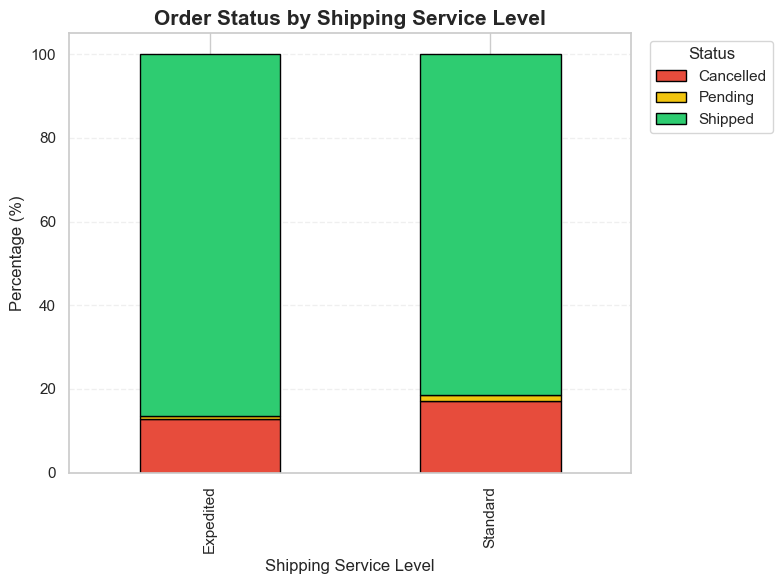

In [217]:
import matplotlib.pyplot as plt

service_status.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#e74c3c', '#f1c40f', '#2ecc71'],
    edgecolor='black'
)

plt.title(
    "Order Status by Shipping Service Level",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Shipping Service Level")
plt.ylabel("Percentage (%)")

plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
'''Encourage customers to opt for expedited shipping where feasible and investigate the reasons behind the higher cancellation rate associated with standard shipping.'''

In [219]:
category_status = (
    pd.crosstab(
        df['category'],
        df['status_group'],
        normalize='index'
    ) * 100
).round(2)

print(category_status)

status_group  Cancelled  Pending  Shipped
category                                 
Blazzer           13.70     1.12    85.18
Perfume           12.94     0.87    86.19
Shirt             14.44     0.83    84.73
Shoes              7.42     0.00    92.58
Socks             14.61     0.57    84.82
T-shirt           14.60     0.81    84.59
Trousers          11.92     0.73    87.35
Wallet            12.33     0.40    87.28
Watch              0.00     0.00   100.00


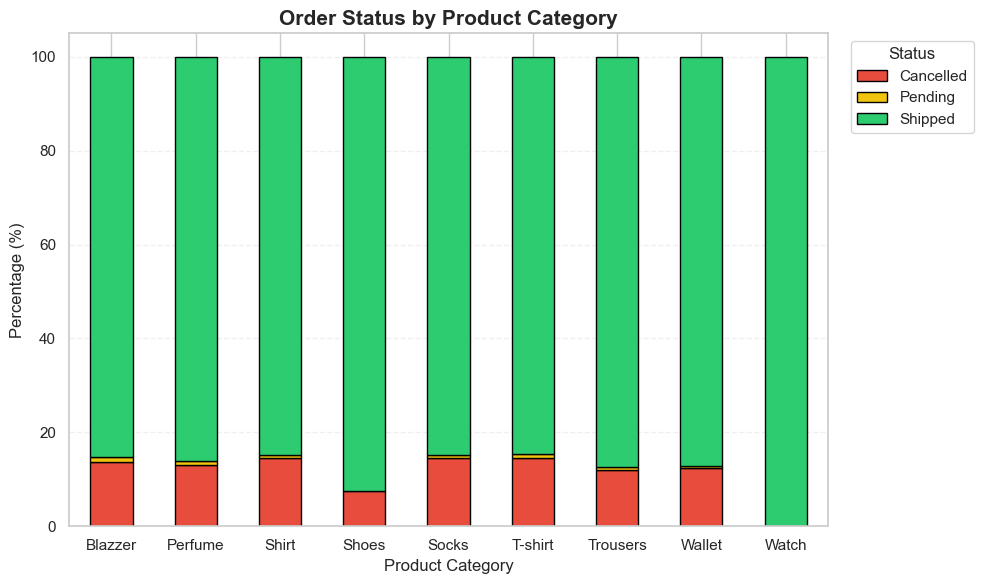

In [220]:
import matplotlib.pyplot as plt

category_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#e74c3c', '#f1c40f', '#2ecc71'],
    edgecolor='black'
)

plt.title(
    "Order Status by Product Category",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Product Category")
plt.ylabel("Percentage (%)")

plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [221]:
cancel_rate = (
    category_status['Cancelled']
    .sort_values(ascending=False)
)

print(cancel_rate)

category
Socks       14.61
T-shirt     14.60
Shirt       14.44
Blazzer     13.70
Perfume     12.94
Wallet      12.33
Trousers    11.92
Shoes        7.42
Watch        0.00
Name: Cancelled, dtype: float64


In [222]:
df['category'].value_counts()

category
Shirt       60643
T-shirt     58320
Blazzer     17472
Trousers    12048
Perfume      1376
Wallet       1006
Socks         527
Shoes         283
Watch           7
Name: count, dtype: int64

In [223]:
category_summary = pd.DataFrame({
    'Orders': df['category'].value_counts(),
    'Cancellation Rate (%)': category_status['Cancelled']
})

print(category_summary)

          Orders  Cancellation Rate (%)
category                               
Blazzer    17472                  13.70
Perfume     1376                  12.94
Shirt      60643                  14.44
Shoes        283                   7.42
Socks        527                  14.61
T-shirt    58320                  14.60
Trousers   12048                  11.92
Wallet      1006                  12.33
Watch          7                   0.00


In [ ]:
'''The three highest-selling categories—Shirts (60,643 orders), T-shirts (58,320 orders), and Blazers (17,472 orders)—all exhibit similar cancellation rates ranging from 13.7% to 14.6%. This suggests a consistent order fulfillment performance across the major apparel categories.'''

In [ ]:
'''The company's core apparel categories (Shirts, T-shirts, Blazers, and Trousers) exhibit comparable cancellation rates, with Trousers showing slightly better fulfillment performance. This consistency suggests that cancellation issues are not isolated to a single high-volume product category but are relatively uniform across the primary apparel portfolio.'''

In [224]:
fulfilment_service = (
    pd.crosstab(
        df['fulfilment'],
        df['ship_service_level'],
        normalize='index'
    ) * 100
).round(2)

print(fulfilment_service)

ship_service_level  Expedited  Standard
fulfilment                             
Amazon                  98.96      1.04
Merchant                 0.00    100.00


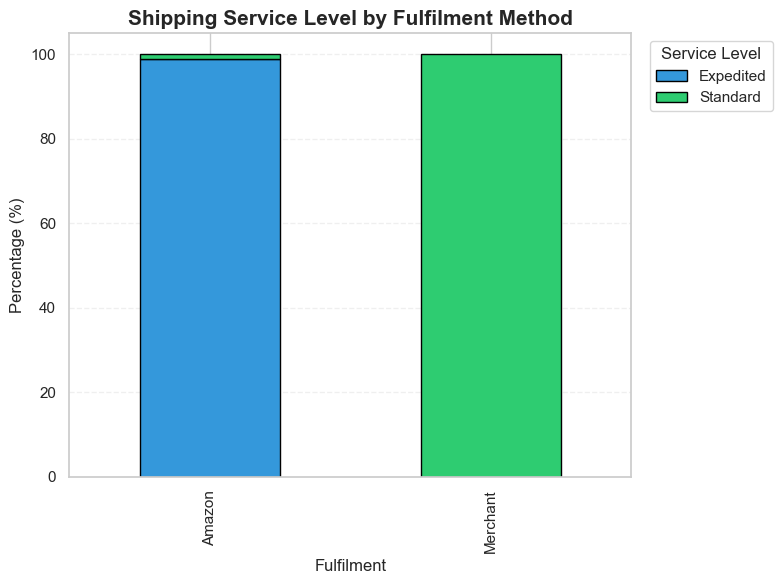

In [225]:


fulfilment_service.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#3498db', '#2ecc71'],
    edgecolor='black'
)

plt.title("Shipping Service Level by Fulfilment Method",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Fulfilment")
plt.ylabel("Percentage (%)")

plt.legend(title="Service Level",
           bbox_to_anchor=(1.02,1),
           loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
'''Amazon-fulfilled orders are almost entirely shipped using the Expedited service (98.96%), whereas Merchant-fulfilled orders rely exclusively on the Standard service level. This indicates a strong operational relationship between fulfilment method and shipping service.'''

In [226]:
fulfilment_category = (
    pd.crosstab(
        df['fulfilment'],
        df['category'],
        normalize='index'
    ) * 100
).round(2)

print(fulfilment_category)

category    Blazzer  Perfume  Shirt  Shoes  Socks  T-shirt  Trousers  Wallet  \
fulfilment                                                                     
Amazon         9.00     0.95  40.88   0.20   0.27    39.29      8.70    0.71   
Merchant      17.12     0.81  37.99   0.16   0.52    36.59      6.26    0.55   

category    Watch  
fulfilment         
Amazon       0.01  
Merchant     0.00  


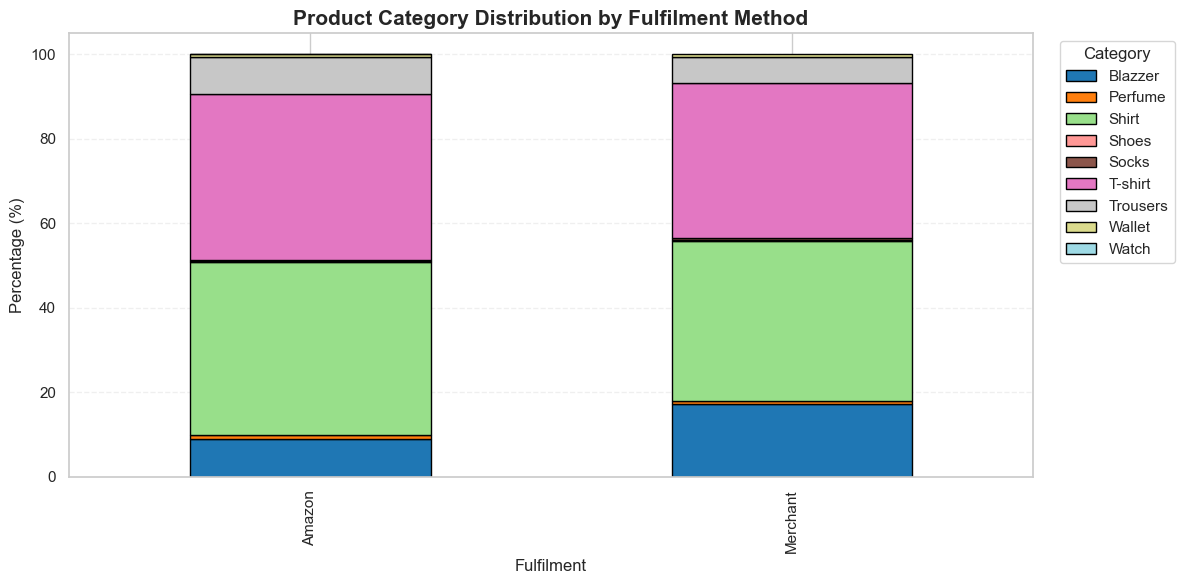

In [227]:
fulfilment_category.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20',
    edgecolor='black'
)

plt.title("Product Category Distribution by Fulfilment Method",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Fulfilment")
plt.ylabel("Percentage (%)")

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [229]:
fulfilment_amount = (
    df.groupby('fulfilment')['amount']
    .agg(
        Orders='count',
        Average_Amount='mean',
        Median_Amount='median',
        Total_Revenue='sum',
        Maximum_Amount='max'
    )
    .round(2)
)

print(fulfilment_amount)

            Orders  Average_Amount  Median_Amount  Total_Revenue  \
fulfilment                                                         
Amazon       97597          647.53         597.00    63196984.00   
Merchant     45176          641.37         622.86    28974584.48   

            Maximum_Amount  
fulfilment                  
Amazon              5584.0  
Merchant            5495.0  


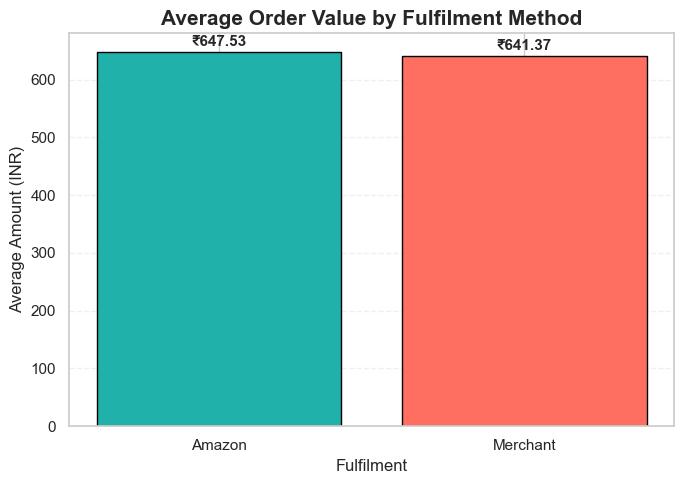

In [230]:
avg_amount = df.groupby('fulfilment')['amount'].mean().round(2)

plt.figure(figsize=(7,5))

bars = plt.bar(
    avg_amount.index,
    avg_amount.values,
    color=['#20B2AA', '#FF6F61'],
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+10,
        f'₹{bar.get_height():.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Average Order Value by Fulfilment Method",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Fulfilment")
plt.ylabel("Average Amount (INR)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

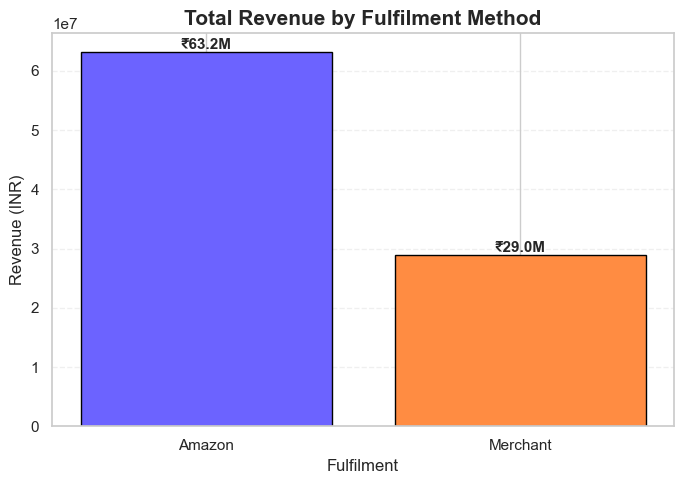

In [231]:
revenue = df.groupby('fulfilment')['amount'].sum()

plt.figure(figsize=(7,5))

bars = plt.bar(
    revenue.index,
    revenue.values,
    color=['#6C63FF', '#FF8C42'],
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+500000,
        f'₹{bar.get_height()/1e6:.1f}M',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Total Revenue by Fulfilment Method",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Fulfilment")
plt.ylabel("Revenue (INR)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
'''Amazon fulfilment generated a higher total revenue (₹63.2 million), primarily because it processed substantially more orders than Merchant fulfilment.'''
'''Although Amazon fulfilment contributes a larger share of total revenue due to higher order volume, the average order value remains nearly the same across both fulfilment methods. This suggests that customer spending patterns are consistent regardless of who fulfils the order.'''
'''Amazon and Merchant fulfilment exhibit very similar average order values. The higher total revenue generated by Amazon is driven by its significantly larger order volume rather than higher-value transactions.'''

In [232]:
(df['sales_channel'].value_counts(normalize=True) * 100).round(2)

sales_channel
Amazon.in     99.92
Non-Amazon     0.08
Name: proportion, dtype: float64

In [233]:
category_amount = (
    df.groupby('category')['amount']
    .agg(
        Orders='count',
        Total_Revenue='sum',
        Average_Order_Value='mean',
        Median_Order_Value='median'
    )
    .round(2)
    .sort_values(by='Total_Revenue', ascending=False)
)

print(category_amount)

          Orders  Total_Revenue  Average_Order_Value  Median_Order_Value
category                                                                
T-shirt    54668    45637811.74               834.82               788.0
Shirt      56916    25889536.98               454.87               435.0
Blazzer    16600    12691905.59               764.57               744.0
Trousers   11546     6102355.60               528.53               523.0
Perfume     1300      954456.54               734.20               837.0
Wallet       959      496836.41               518.08               545.0
Shoes        274      212666.76               776.16               790.0
Socks        503      183863.86               365.53               345.0
Watch          7        2135.00               305.00               305.0


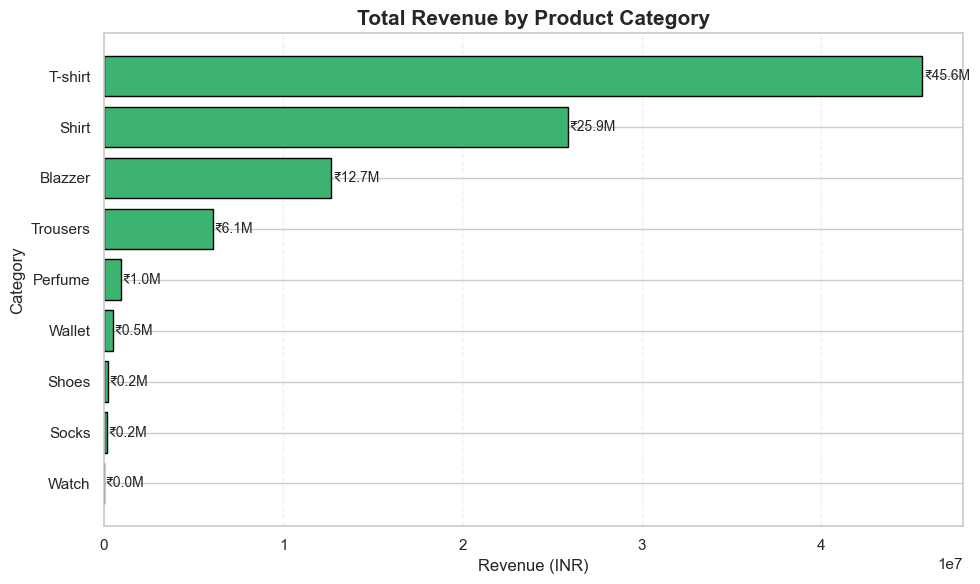

In [235]:
import matplotlib.pyplot as plt

revenue = (
    df.groupby('category')['amount']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    revenue.index,
    revenue.values,
    color='mediumseagreen',
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_width()+100000,
        bar.get_y()+bar.get_height()/2,
        f'₹{bar.get_width()/1e6:.1f}M',
        va='center',
        fontsize=10
    )

plt.title("Total Revenue by Product Category",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Revenue (INR)")
plt.ylabel("Category")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

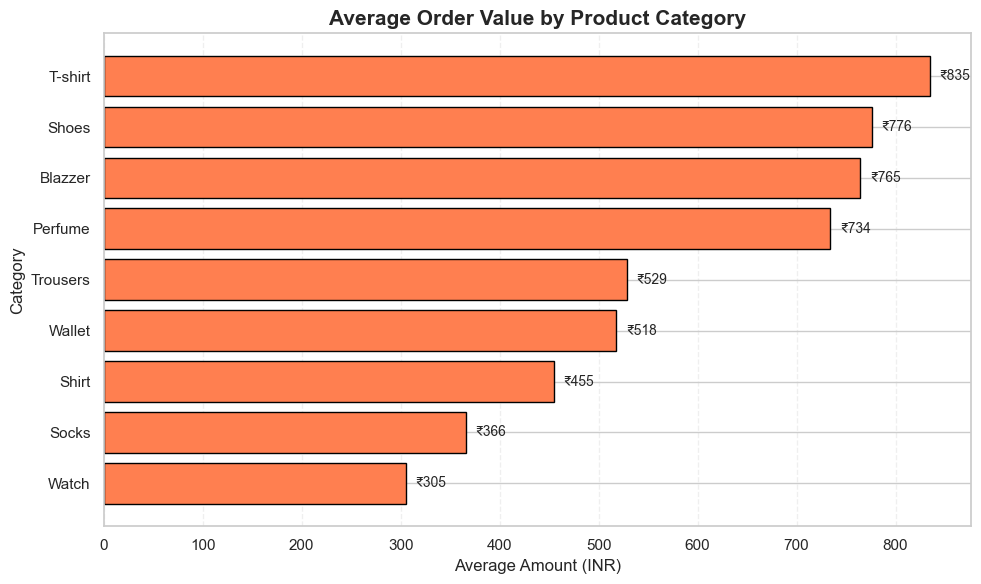

In [236]:
avg_amount = (
    df.groupby('category')['amount']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    avg_amount.index,
    avg_amount.values,
    color='coral',
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_width()+10,
        bar.get_y()+bar.get_height()/2,
        f'₹{bar.get_width():.0f}',
        va='center',
        fontsize=10
    )

plt.title("Average Order Value by Product Category",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Average Amount (INR)")
plt.ylabel("Category")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
'''T-shirts are the highest revenue-generating product category, contributing approximately ₹45.6 million in sales, followed by Shirts (₹25.9 million) and Blazers (₹12.7 million).'''
'''The majority of the company's revenue is generated from apparel products, with T-shirts, Shirts, Blazers, and Trousers contributing the largest share of total sales.'''

In [ ]:
'''T-shirts not only generate the highest total revenue but also have the highest average order value (₹834.82), making them the most valuable product category in the dataset.'''

In [237]:
category_month = (
    pd.crosstab(
        df['month'],
        df['category'],
        normalize='index'
    ) * 100
).round(2)

print(category_month)

category  Blazzer  Perfume  Shirt  Shoes  Socks  T-shirt  Trousers  Wallet  \
month                                                                        
April        8.29     0.70  41.42   0.31   0.35    40.58      7.58    0.78   
June        13.08     0.92  41.69   0.10   0.31    36.62      6.81    0.45   
March        4.39     0.49  47.80   0.00   0.00    42.44      4.39    0.49   
May         13.90     1.14  36.75   0.12   0.38    37.59      9.40    0.72   

category  Watch  
month            
April      0.00  
June       0.02  
March      0.00  
May        0.00  


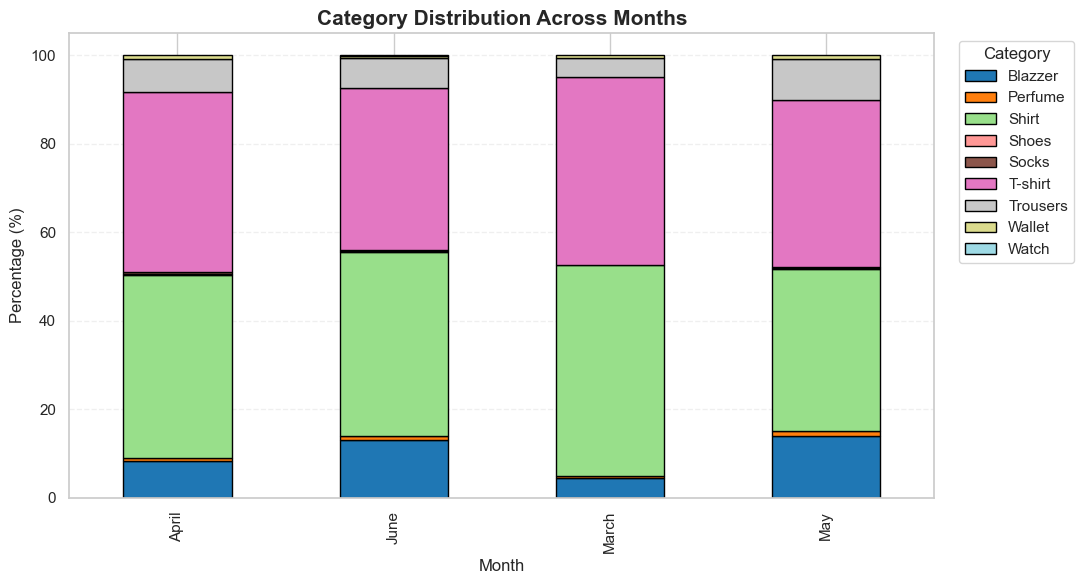

In [238]:
category_month.plot(
    kind='bar',
    stacked=True,
    figsize=(11,6),
    colormap='tab20',
    edgecolor='black'
)

plt.title("Category Distribution Across Months",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Month")
plt.ylabel("Percentage (%)")

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [239]:
category_month_revenue = (
    df.pivot_table(
        values='amount',
        index='month',
        columns='category',
        aggfunc='sum'
    )
)

print(category_month_revenue)

category     Blazzer    Perfume       Shirt      Shoes     Socks      T-shirt  \
month                                                                           
April     3397782.75  286638.41  9703247.15  128259.24  70368.97  18020236.85   
June      4308286.52  287658.67  8005787.00   34438.90  45829.68  12796560.57   
March        7653.28    1099.00    41435.57        NaN       NaN     61905.00   
May       4978183.04  379060.46  8139067.26   49968.62  67665.21  14759109.32   

category    Trousers     Wallet   Watch  
month                                    
April     2031831.84  210026.21     NaN  
June      1750011.15  111865.95  2135.0  
March        4511.00     280.00     NaN  
May       2316001.61  174664.25     NaN  


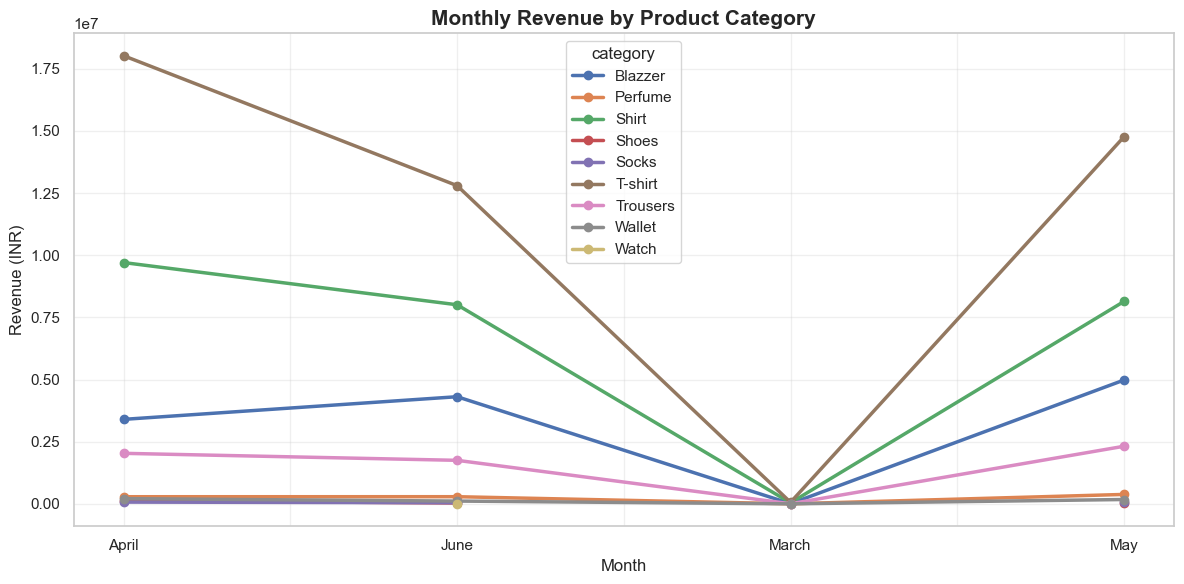

In [240]:
category_month_revenue.plot(
    figsize=(12,6),
    marker='o',
    linewidth=2.5
)

plt.title("Monthly Revenue by Product Category",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [241]:
state_revenue = (
    df.groupby('ship_state')['amount']
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue.head(10))

ship_state
Maharashtra       15715497.53
Karnataka         12083153.87
Telangana          8510855.04
Tamil Nadu         8144759.97
Uttar Pradesh      7791848.12
Delhi              4986682.74
Kerala             4526623.26
West Bengal        3971613.96
Andhra Pradesh     3925606.34
Haryana            3326870.17
Name: amount, dtype: float64


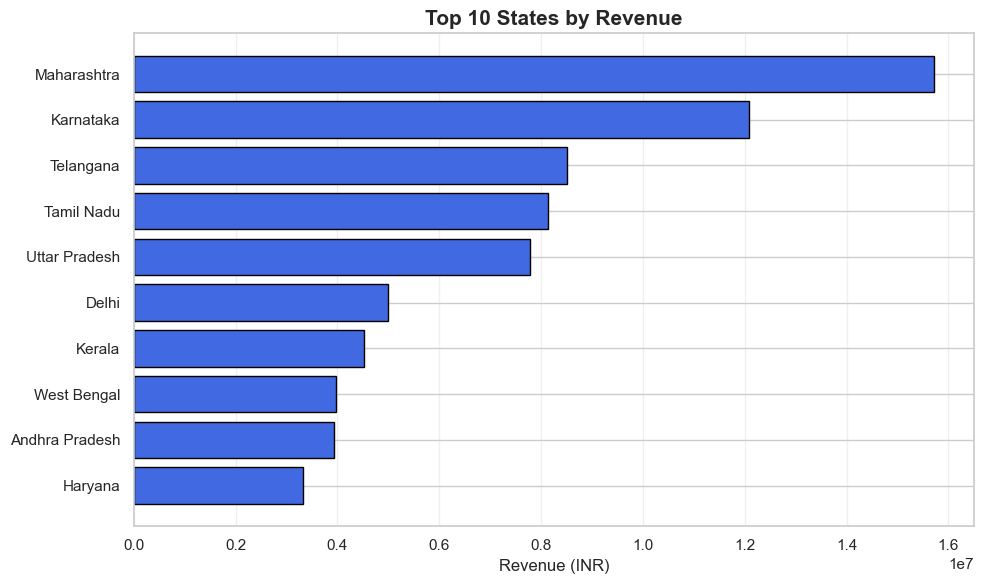

In [242]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    state_revenue.head(10).sort_values().index,
    state_revenue.head(10).sort_values().values,
    color='royalblue',
    edgecolor='black'
)

plt.title("Top 10 States by Revenue",fontsize=15,fontweight='bold')
plt.xlabel("Revenue (INR)")
plt.grid(axis='x',alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
'''The top five states—Maharashtra, Karnataka, Telangana, Tamil Nadu, and Uttar Pradesh—contribute a significant share of the company's overall revenue, indicating strong demand in these regions.'''
'''Maharashtra generated the highest revenue (₹15.72 million), followed by Karnataka (₹12.08 million). These two states are the company's strongest revenue-generating markets.'''
'''The company should prioritize inventory availability, targeted marketing campaigns, and customer retention initiatives in its top-performing states to maximize future revenue growth.'''

In [243]:
state_orders = (
    df['ship_state']
    .value_counts()
    .head(10)
)

print(state_orders)

ship_state
Maharashtra       26258
Karnataka         20196
Tamil Nadu        14328
Telangana         13933
Uttar Pradesh     12088
Delhi              8035
Kerala             7913
West Bengal        6716
Andhra Pradesh     6645
Gujarat            5288
Name: count, dtype: int64


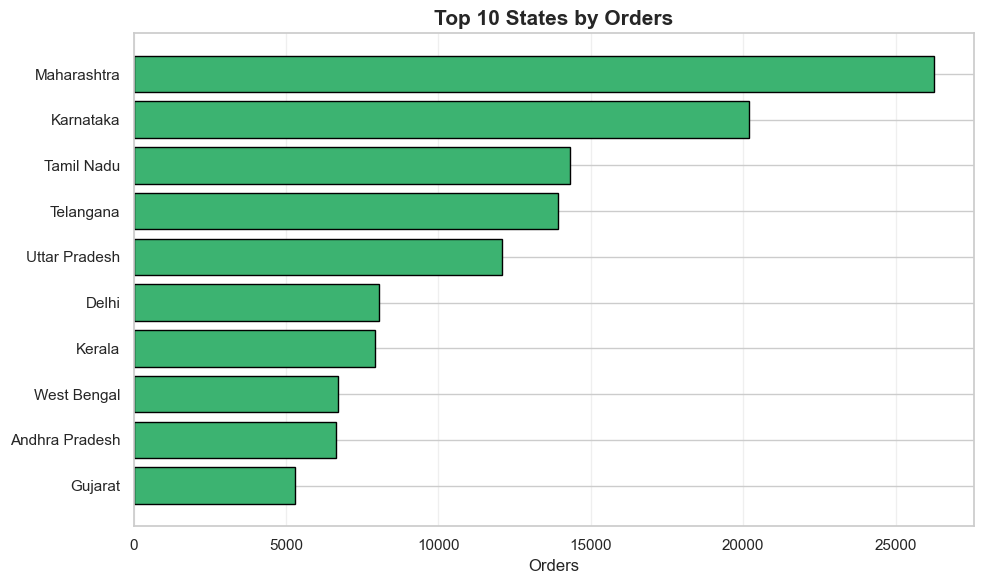

In [244]:
plt.figure(figsize=(10,6))

bars=plt.barh(
    state_orders.sort_values().index,
    state_orders.sort_values().values,
    color='mediumseagreen',
    edgecolor='black'
)

plt.title("Top 10 States by Orders",fontsize=15,fontweight='bold')
plt.xlabel("Orders")
plt.grid(axis='x',alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
'''Higher revenue is primarily driven by a higher number of orders rather than significantly higher spending per customer.'''
'''The close alignment between order volume and revenue across the top-performing states indicates that higher revenue is primarily driven by greater sales volume rather than higher spending'''
'''Karnataka, Tamil Nadu, Telangana, and Uttar Pradesh also emerged as major contributors, collectively accounting for a significant portion of total sales and revenue.'''

In [245]:
month_revenue = (
    df.groupby('month')['amount']
    .sum()
)

print(month_revenue)

month
April    33848391.42
June     27342573.44
March      116883.85
May      30863719.77
Name: amount, dtype: float64


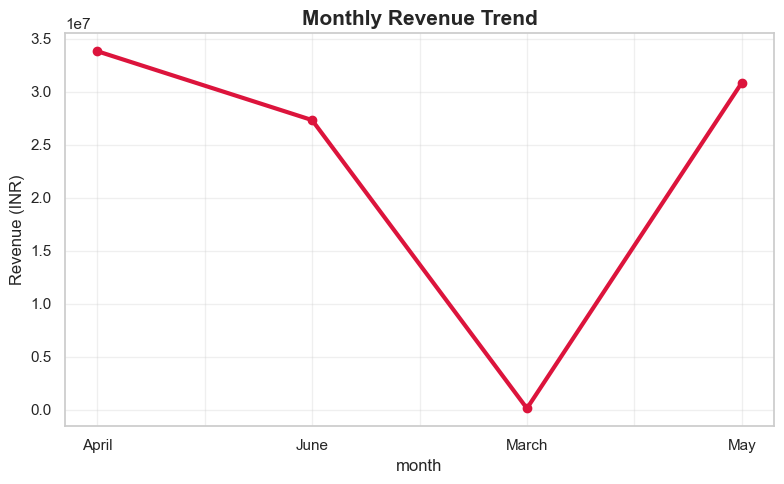

In [246]:
month_revenue.plot(
    marker='o',
    linewidth=3,
    figsize=(8,5),
    color='crimson'
)

plt.title("Monthly Revenue Trend",fontsize=15,fontweight='bold')
plt.ylabel("Revenue (INR)")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

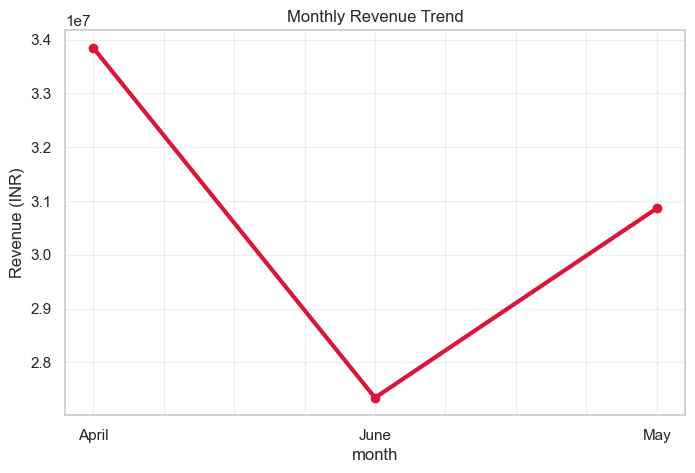

In [256]:
month_revenue = (
    df[df['month'] != 'March']
    .groupby('month')['amount']
    .sum()
)

month_revenue.plot(
    marker='o',
    linewidth=3,
    figsize=(8,5),
    color='crimson'
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (INR)")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
'''April generated the highest revenue (₹33.85 million), followed by May (₹30.86 million) and June (₹27.34 million).'''
'''March recorded negligible revenue because the dataset contains only a small fraction of orders for that month. Therefore, March should not be used for trend comparison.'''
'''Revenue remained consistently high across April, May, and June, indicating stable sales performance during the primary analysis period.'''

In [247]:
month_orders = df['month'].value_counts().sort_index()

print(month_orders)

month
April    57606
June     44317
March      205
May      49554
Name: count, dtype: int64


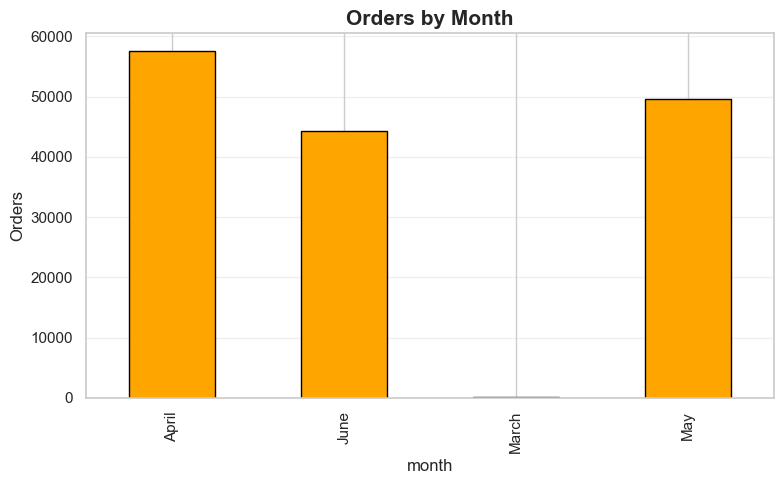

In [248]:
month_orders.plot(
    kind='bar',
    color='orange',
    edgecolor='black',
    figsize=(8,5)
)

plt.title("Orders by Month",fontsize=15,fontweight='bold')
plt.ylabel("Orders")
plt.grid(axis='y',alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
'''April recorded the highest number of orders (57,606) and generated the highest revenue (₹33.85 million), making it the best-performing month in the dataset.'''
'''A gradual decline in both order volume and revenue is observed from April to June, suggesting a decrease in sales activity over the analysis period.'''
'''March contains only 205 orders (0.14% of the dataset), indicating that it represents partial data. Therefore, March was excluded from trend interpretation.'''

In [249]:
weekday_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_revenue=(
    df.groupby('weekday')['amount']
    .sum()
    .reindex(weekday_order)
)

print(weekday_revenue)

weekday
Monday       13393536.53
Tuesday      13449194.71
Wednesday    13170512.20
Thursday     12035159.72
Friday       12546414.59
Saturday     13380897.17
Sunday       14195853.56
Name: amount, dtype: float64


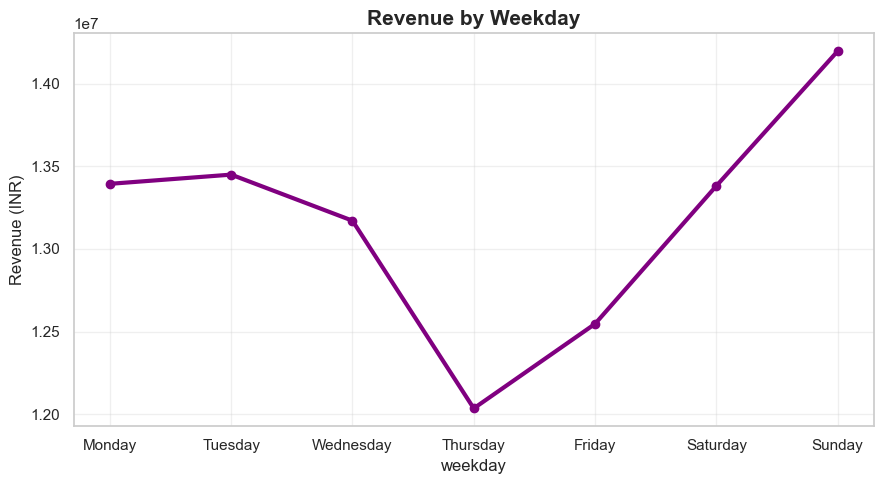

In [250]:
weekday_revenue.plot(
    marker='o',
    linewidth=3,
    figsize=(9,5),
    color='purple'
)

plt.title("Revenue by Weekday",fontsize=15,fontweight='bold')
plt.ylabel("Revenue (INR)")
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
'''Sunday generated the highest revenue (₹14.20 million), making it the strongest sales day of the week.'''
'''Revenue remains relatively consistent throughout the week, with only modest variations between weekdays.'''
'''Revenue is relatively stable, with Sunday showing a slight lead.'''
'''The company can consider scheduling promotional campaigns or product launches during weekends, particularly on Sundays, to capitalize on slightly higher customer spending.'''

In [251]:
weekday_orders=(
    df['weekday']
    .value_counts()
    .reindex(weekday_order)
)

print(weekday_orders)

weekday
Monday       22047
Tuesday      22252
Wednesday    21978
Thursday     19856
Friday       20567
Saturday     21758
Sunday       23224
Name: count, dtype: int64


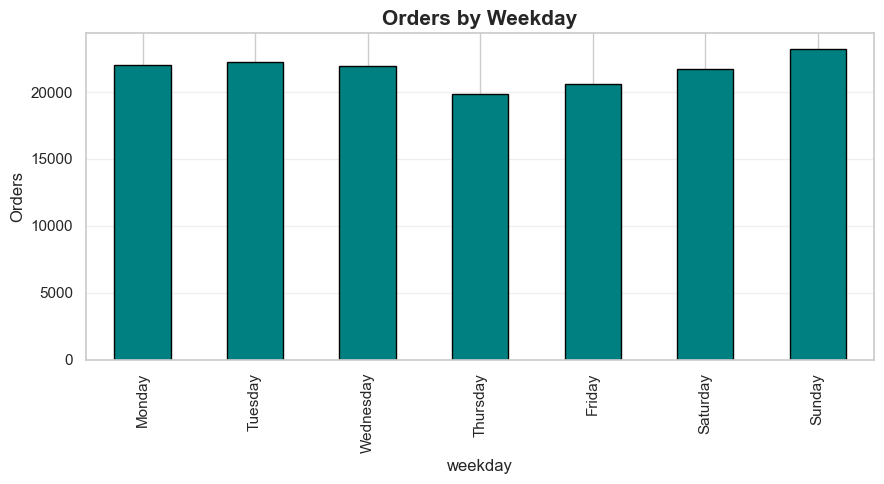

In [252]:
weekday_orders.plot(
    kind='bar',
    figsize=(9,5),
    color='teal',
    edgecolor='black'
)

plt.title("Orders by Weekday",fontsize=15,fontweight='bold')
plt.ylabel("Orders")
plt.grid(axis='y',alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
'''Sunday recorded the highest number of orders (23,224) and generated the highest revenue (₹14.20 million), making it the strongest sales day of the week.'''
'''Thursday recorded the lowest order volume (19,856) and the lowest revenue (₹12.04 million), indicating comparatively lower customer activity on that day.'''
'''The close relationship between weekday order volume and revenue suggests that higher revenue is primarily driven by an increase in the number of orders rather than a higher average order value.'''
'''The company can schedule promotional campaigns, product launches, or special discounts on Thursdays to boost customer engagement, while leveraging Sundays for premium offers and marketing campaigns due to their consistently higher sales performance.'''

In [253]:
b2b_summary=(
    df.groupby('b2b')['amount']
    .agg(
        Orders='count',
        Revenue='sum',
        Average_Order_Value='mean'
    )
    .round(2)
)

print(b2b_summary)

       Orders      Revenue  Average_Order_Value
b2b                                            
False  141756  91465721.72               645.23
True     1017    705846.76               694.05


In [ ]:
'''The business is predominantly Business-to-Consumer (B2C), with over 99% of orders coming from non-B2B customers.'''
'''Although B2B orders account for a very small share of total orders, they have a higher average order value (₹694.05) compared to B2C orders (₹645.23).'''
'''Despite the higher average order value, B2B contributes only a small fraction of total revenue due to its very low order volume.'''
'''The company can explore expanding its B2B customer base through bulk-order programs, corporate partnerships, or wholesale initiatives, as B2B customers demonstrate higher average spending per order.'''

In [254]:
category_qty=(
    df.groupby('category')['qty']
    .sum()
    .sort_values(ascending=False)
)

print(category_qty)

category
Shirt       54861
T-shirt     52544
Blazzer     15767
Trousers    11234
Perfume      1248
Wallet        937
Socks         470
Shoes         274
Watch           7
Name: qty, dtype: int64


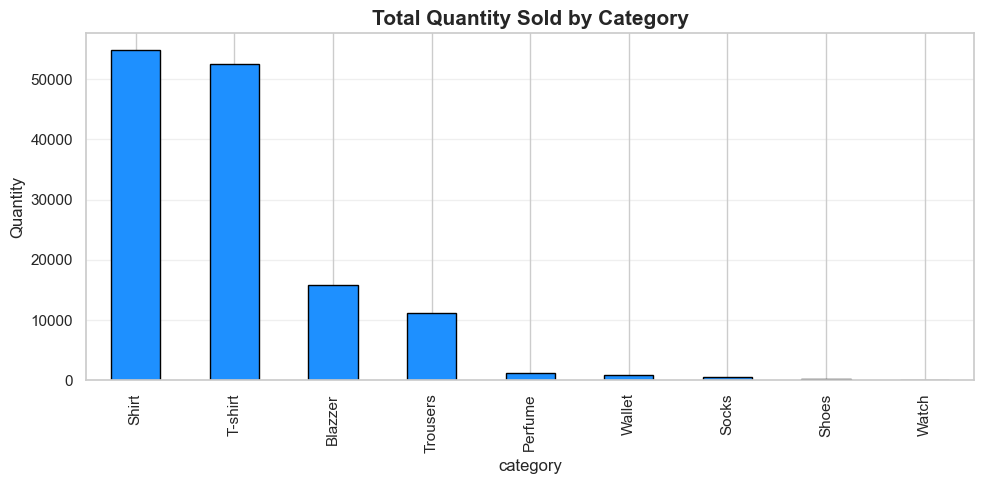

In [255]:
category_qty.plot(
    kind='bar',
    figsize=(10,5),
    color='dodgerblue',
    edgecolor='black'
)

plt.title("Total Quantity Sold by Category",fontsize=15,fontweight='bold')
plt.ylabel("Quantity")

plt.grid(axis='y',alpha=.3)

plt.tight_layout()
plt.show()

In [ ]:
'''Shirts and T-shirts account for the highest quantity sold, together contributing the majority of total units purchased. This indicates strong and consistent customer demand for these apparel categories.'''
'''Blazers and Trousers represent the next largest product categories, while accessories such as Wallets, Perfumes, Socks, Shoes, and Watches contribute only a small fraction of total units sold.'''